In [4]:
# ============================================================
# 1. Imports
# ============================================================
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from scipy.stats import spearmanr
import itertools
import os

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# ============================================================
# 2. Load Training Data
# ============================================================
with open('/content/train.json') as f:
    raw = json.load(f)

def build_story(item):
    return ' '.join([
        item.get('precontext', ''),
        item.get('sentence', ''),
        item.get('ending', '')
    ])

def build_meaning(item):
    return item.get('judged_meaning', '')

items    = list(raw.values())
stories  = [build_story(i) for i in items]
meanings = [build_meaning(i) for i in items]
labels   = np.array([i['average'] for i in items], dtype=np.float32)
stdevs   = np.array([i['stdev']   for i in items], dtype=np.float32)

# ============================================================
# 3. Tokenization (manual, mirrors Keras behaviour)
# ============================================================
MAX_WORDS = 10000
MAX_LEN   = 150

def build_vocab(texts, max_words):
    from collections import Counter
    counter = Counter()
    for t in texts:
        counter.update(t.lower().split())
    vocab = ['<PAD>', '<OOV>'] + [w for w, _ in counter.most_common(max_words - 2)]
    word2idx = {w: i for i, w in enumerate(vocab)}
    return word2idx

word2idx = build_vocab(stories + meanings, MAX_WORDS)
PAD_IDX  = word2idx['<PAD>']
OOV_IDX  = word2idx['<OOV>']

def encode(texts, word2idx, max_len):
    seqs = []
    for text in texts:
        ids = [word2idx.get(w, OOV_IDX) for w in text.lower().split()][:max_len]
        ids += [PAD_IDX] * (max_len - len(ids))
        seqs.append(ids)
    return np.array(seqs, dtype=np.int64)

X_story = encode(stories,  word2idx, MAX_LEN)
X_mean  = encode(meanings, word2idx, MAX_LEN)

(Xs_train, Xs_val,
 Xm_train, Xm_val,
 y_train,  y_val,
 s_train,  s_val) = train_test_split(
    X_story, X_mean, labels, stdevs,
    test_size=0.15, random_state=42
)

# ============================================================
# 4. Load GloVe Embeddings  (trainable=True)
# ============================================================
GLOVE_PATH = '/content/glove.6B.100d.txt'
EMBED_DIM  = 100

if not os.path.exists(GLOVE_PATH):
    raise FileNotFoundError("Download GloVe first: glove.6B.100d.txt")

glove_index = {}
with open(GLOVE_PATH, encoding='utf8') as f:
    for line in f:
        values = line.split()
        glove_index[values[0]] = np.asarray(values[1:], dtype='float32')

num_words        = min(MAX_WORDS, len(word2idx))
embedding_matrix = np.zeros((num_words, EMBED_DIM), dtype=np.float32)
for word, i in word2idx.items():
    if i < num_words and word in glove_index:
        embedding_matrix[i] = glove_index[word]

# ============================================================
# 5. PyTorch Dataset
# ============================================================
class StoryDataset(Dataset):
    def __init__(self, X_story, X_mean, labels):
        self.X_story = torch.tensor(X_story, dtype=torch.long)
        self.X_mean  = torch.tensor(X_mean,  dtype=torch.long)
        self.labels  = torch.tensor(labels,  dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.X_story[idx], self.X_mean[idx], self.labels[idx]

train_ds = StoryDataset(Xs_train, Xm_train, y_train)
val_ds   = StoryDataset(Xs_val,   Xm_val,   y_val)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2)

# ============================================================
# 6. Attention Block
# ============================================================
class AttentionBlock(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.score = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, seq_len, hidden_dim)
        scores  = torch.tanh(self.score(x))          # (batch, seq_len, 1)
        weights = torch.softmax(scores, dim=1)        # (batch, seq_len, 1)
        return x * weights                            # (batch, seq_len, hidden_dim)

# ============================================================
# 7. Encoder (BiSimpleRNN + Attention + GlobalAvgPool)
# ============================================================
class Encoder(nn.Module):
    def __init__(self, num_words, embed_dim, embedding_matrix,
                 rnn_units, num_layers, dropout, l2_reg):
        super().__init__()

        # Trainable GloVe embedding
        self.embedding = nn.Embedding(num_words, embed_dim, padding_idx=PAD_IDX)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32),
            requires_grad=True   # <-- trainable
        )

        self.rnns = nn.ModuleList()
        in_size   = embed_dim
        for _ in range(num_layers):
            self.rnns.append(
                nn.RNN(
                    in_size, rnn_units,
                    batch_first=True,
                    bidirectional=True,
                    dropout=0.1 if num_layers > 1 else 0.0
                )
            )
            in_size = rnn_units * 2  # bidirectional doubles output

        self.dropout   = nn.Dropout(dropout)
        self.attention = AttentionBlock(rnn_units * 2)
        self.l2_reg    = l2_reg

    def forward(self, x):
        x = self.embedding(x)           # (batch, seq_len, embed_dim)
        x = self.dropout(x)

        for rnn in self.rnns:
            x, _ = rnn(x)               # (batch, seq_len, rnn_units*2)
            x = self.dropout(x)

        x = self.attention(x)           # (batch, seq_len, rnn_units*2)
        x = x.mean(dim=1)               # global average pool → (batch, rnn_units*2)
        return x

# ============================================================
# 8. Dual-Encoder Comparison Model
# ============================================================
class DualEncoderModel(nn.Module):
    def __init__(self, num_words, embed_dim, embedding_matrix,
                 rnn_units, num_layers, dropout, l2_reg, dense_units):
        super().__init__()

        enc_kwargs = dict(
            num_words=num_words,
            embed_dim=embed_dim,
            embedding_matrix=embedding_matrix,
            rnn_units=rnn_units,
            num_layers=num_layers,
            dropout=dropout,
            l2_reg=l2_reg
        )
        self.story_encoder   = Encoder(**enc_kwargs)
        self.meaning_encoder = Encoder(**enc_kwargs)

        vec_dim = rnn_units * 2          # each encoder output size
        self.head = nn.Sequential(
            nn.Linear(vec_dim * 3, dense_units),  # story + meaning + |diff|
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(dense_units, 1)
        )

    def forward(self, story, meaning):
        sv = self.story_encoder(story)    # (batch, vec_dim)
        mv = self.meaning_encoder(meaning)

        diff     = (sv - mv).abs()
        combined = torch.cat([sv, mv, diff], dim=-1)
        return self.head(combined).squeeze(-1)

    def l2_loss(self):
        """Collect L2 penalty from both encoders."""
        total = 0.0
        for enc in (self.story_encoder, self.meaning_encoder):
            for rnn in enc.rnns:
                for name, param in rnn.named_parameters():
                    if 'weight' in name:
                        total += enc.l2_reg * param.pow(2).sum()
        return total

# ============================================================
# 9. Training & Evaluation Helpers
# ============================================================
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for story, meaning, label in loader:
        story, meaning, label = story.to(DEVICE), meaning.to(DEVICE), label.to(DEVICE)
        optimizer.zero_grad()
        pred = model(story, meaning)
        loss = nn.functional.mse_loss(pred, label) + model.l2_loss()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item() * len(label)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_loader(model, loader):
    model.eval()
    preds_all, labels_all = [], []
    for story, meaning, label in loader:
        story, meaning = story.to(DEVICE), meaning.to(DEVICE)
        pred = model(story, meaning).cpu().numpy()
        preds_all.append(pred)
        labels_all.append(label.numpy())
    return np.concatenate(preds_all), np.concatenate(labels_all)

def semeval_metrics(preds, labels, stdevs):
    preds  = np.clip(preds, 1, 5)
    stdevs = np.maximum(stdevs, 1.0)
    rho    = spearmanr(labels, preds).correlation
    acc    = np.mean(np.abs(preds - labels) <= stdevs)
    mae    = np.mean(np.abs(preds - labels))
    return rho, acc, mae

# ============================================================
# 10. Hyperparameter Grid Search (replaces Keras Tuner)
# ============================================================
HP_GRID = {
    'rnn_units':   [64, 128],
    'num_layers':  [1, 2],
    'dropout':     [0.2, 0.3, 0.4],
    'l2_reg':      [1e-4, 1e-3],
    'dense_units': [64, 128],
    'lr':          [1e-3, 5e-4, 1e-4],
}

def grid_combinations(grid, max_trials=12):
    keys   = list(grid.keys())
    combos = list(itertools.product(*grid.values()))
    np.random.shuffle(combos)
    return [dict(zip(keys, c)) for c in combos[:max_trials]]

best_val_mae = float('inf')
best_hp      = None
best_state   = None

for trial_idx, hp in enumerate(grid_combinations(HP_GRID, max_trials=12)):
    print(f"\n── Trial {trial_idx+1}/12 | {hp}")

    model = DualEncoderModel(
        num_words        = num_words,
        embed_dim        = EMBED_DIM,
        embedding_matrix = embedding_matrix,
        rnn_units        = hp['rnn_units'],
        num_layers       = hp['num_layers'],
        dropout          = hp['dropout'],
        l2_reg           = hp['l2_reg'],
        dense_units      = hp['dense_units']
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=hp['lr'])
    scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    patience_counter = 0
    best_trial_mae   = float('inf')
    best_trial_state = None

    for epoch in range(30):
        train_loss = train_one_epoch(model, train_loader, optimizer)
        val_preds, val_labels = evaluate_loader(model, val_loader)
        val_mae = np.mean(np.abs(np.clip(val_preds, 1, 5) - val_labels))
        scheduler.step(val_mae)

        if val_mae < best_trial_mae:
            best_trial_mae   = val_mae
            best_trial_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 5:
                print(f"  Early stop at epoch {epoch+1} | best val_mae={best_trial_mae:.4f}")
                break

    if best_trial_mae < best_val_mae:
        best_val_mae = best_trial_mae
        best_hp      = hp
        best_state   = best_trial_state
        print(f"  ★ New best val_mae={best_val_mae:.4f}")

print(f"\nBest HP: {best_hp}")
print(f"Best val MAE: {best_val_mae:.4f}")

# ============================================================
# 11. Rebuild Best Model & Final Evaluation
# ============================================================
best_model = DualEncoderModel(
    num_words        = num_words,
    embed_dim        = EMBED_DIM,
    embedding_matrix = embedding_matrix,
    rnn_units        = best_hp['rnn_units'],
    num_layers       = best_hp['num_layers'],
    dropout          = best_hp['dropout'],
    l2_reg           = best_hp['l2_reg'],
    dense_units      = best_hp['dense_units']
).to(DEVICE)
best_model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

val_preds, val_labels = evaluate_loader(best_model, val_loader)
rho, acc, mae = semeval_metrics(val_preds, val_labels, s_val)

print("\n── Validation Results ──")
print(f"Spearman r           : {rho:.4f}")
print(f"Accuracy within std  : {acc:.4f}")
print(f"MAE                  : {mae:.4f}")

# ============================================================
# 12. Predict on Test Set
# ============================================================
with open('/content/test.json') as f:
    test_raw = json.load(f)

test_items  = list(test_raw.values())
test_story  = encode([build_story(i)   for i in test_items], word2idx, MAX_LEN)
test_mean_  = encode([build_meaning(i) for i in test_items], word2idx, MAX_LEN)

test_ds     = StoryDataset(test_story, test_mean_, np.zeros(len(test_items), dtype=np.float32))
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

test_preds, _ = evaluate_loader(best_model, test_loader)
test_preds    = np.clip(test_preds, 1, 5)

print("\nSample Test Predictions:")
for i in range(min(10, len(test_preds))):
    print(f"Sample {i+1}: {test_preds[i]:.3f}")

# ============================================================
# 13. Save Best Model
# ============================================================
torch.save({
    'model_state': best_model.state_dict(),
    'best_hp':     best_hp,
    'word2idx':    word2idx,
}, '/content/best_model.pt')
print("\nModel saved to /content/best_model.pt")

Using device: cuda

── Trial 1/12 | {'rnn_units': 128, 'num_layers': 1, 'dropout': 0.4, 'l2_reg': 0.001, 'dense_units': 128, 'lr': 0.001}
  Early stop at epoch 15 | best val_mae=1.0524
  ★ New best val_mae=1.0524

── Trial 2/12 | {'rnn_units': 64, 'num_layers': 1, 'dropout': 0.4, 'l2_reg': 0.0001, 'dense_units': 128, 'lr': 0.001}
  Early stop at epoch 12 | best val_mae=1.0403
  ★ New best val_mae=1.0403

── Trial 3/12 | {'rnn_units': 64, 'num_layers': 2, 'dropout': 0.3, 'l2_reg': 0.0001, 'dense_units': 64, 'lr': 0.0001}


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:641: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  super().__init__(mode, *args, **kwargs)


  Early stop at epoch 6 | best val_mae=2.0959

── Trial 4/12 | {'rnn_units': 64, 'num_layers': 1, 'dropout': 0.2, 'l2_reg': 0.001, 'dense_units': 64, 'lr': 0.0001}
  Early stop at epoch 6 | best val_mae=2.0959

── Trial 5/12 | {'rnn_units': 64, 'num_layers': 2, 'dropout': 0.4, 'l2_reg': 0.001, 'dense_units': 128, 'lr': 0.0001}
  Early stop at epoch 6 | best val_mae=2.0959

── Trial 6/12 | {'rnn_units': 128, 'num_layers': 2, 'dropout': 0.3, 'l2_reg': 0.001, 'dense_units': 128, 'lr': 0.001}
  Early stop at epoch 9 | best val_mae=1.0524

── Trial 7/12 | {'rnn_units': 64, 'num_layers': 2, 'dropout': 0.3, 'l2_reg': 0.001, 'dense_units': 128, 'lr': 0.0005}
  Early stop at epoch 17 | best val_mae=1.0081
  ★ New best val_mae=1.0081

── Trial 8/12 | {'rnn_units': 64, 'num_layers': 1, 'dropout': 0.2, 'l2_reg': 0.001, 'dense_units': 128, 'lr': 0.001}
  Early stop at epoch 15 | best val_mae=1.0214

── Trial 9/12 | {'rnn_units': 128, 'num_layers': 1, 'dropout': 0.4, 'l2_reg': 0.0001, 'dense_units':

In [2]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-03-06 13:53:39--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-06 13:53:40--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-06 13:53:40--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [3]:
!unzip glove.6B.zip

Archive:  glove.6B.zip
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       


Spearman r            : 0.1856
Accuracy within std   : 0.5702
Mean residual         : -0.0265


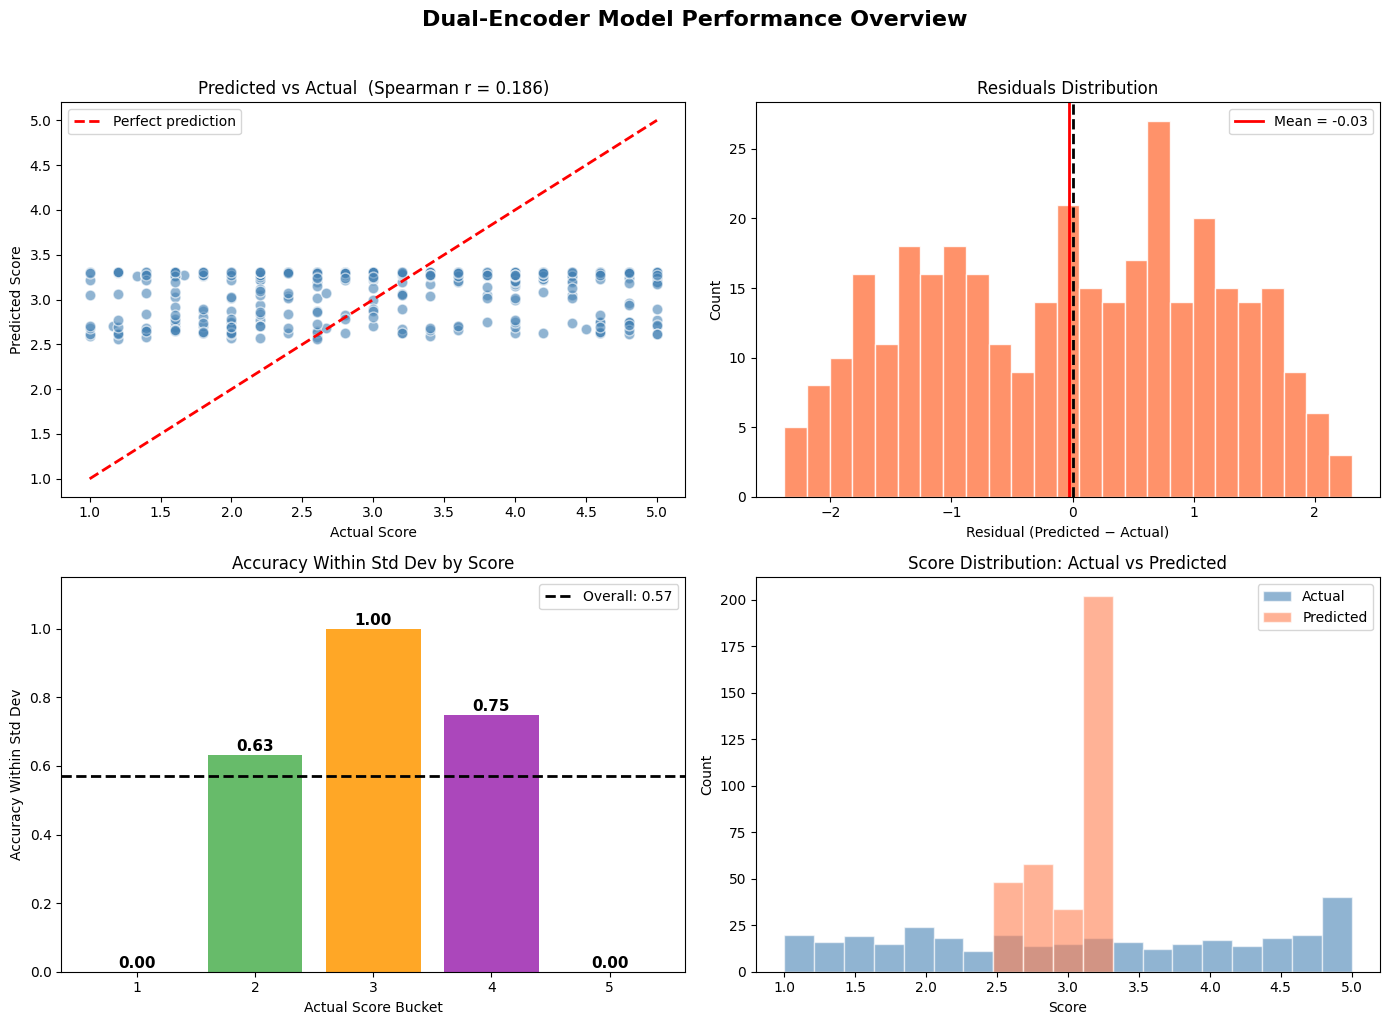

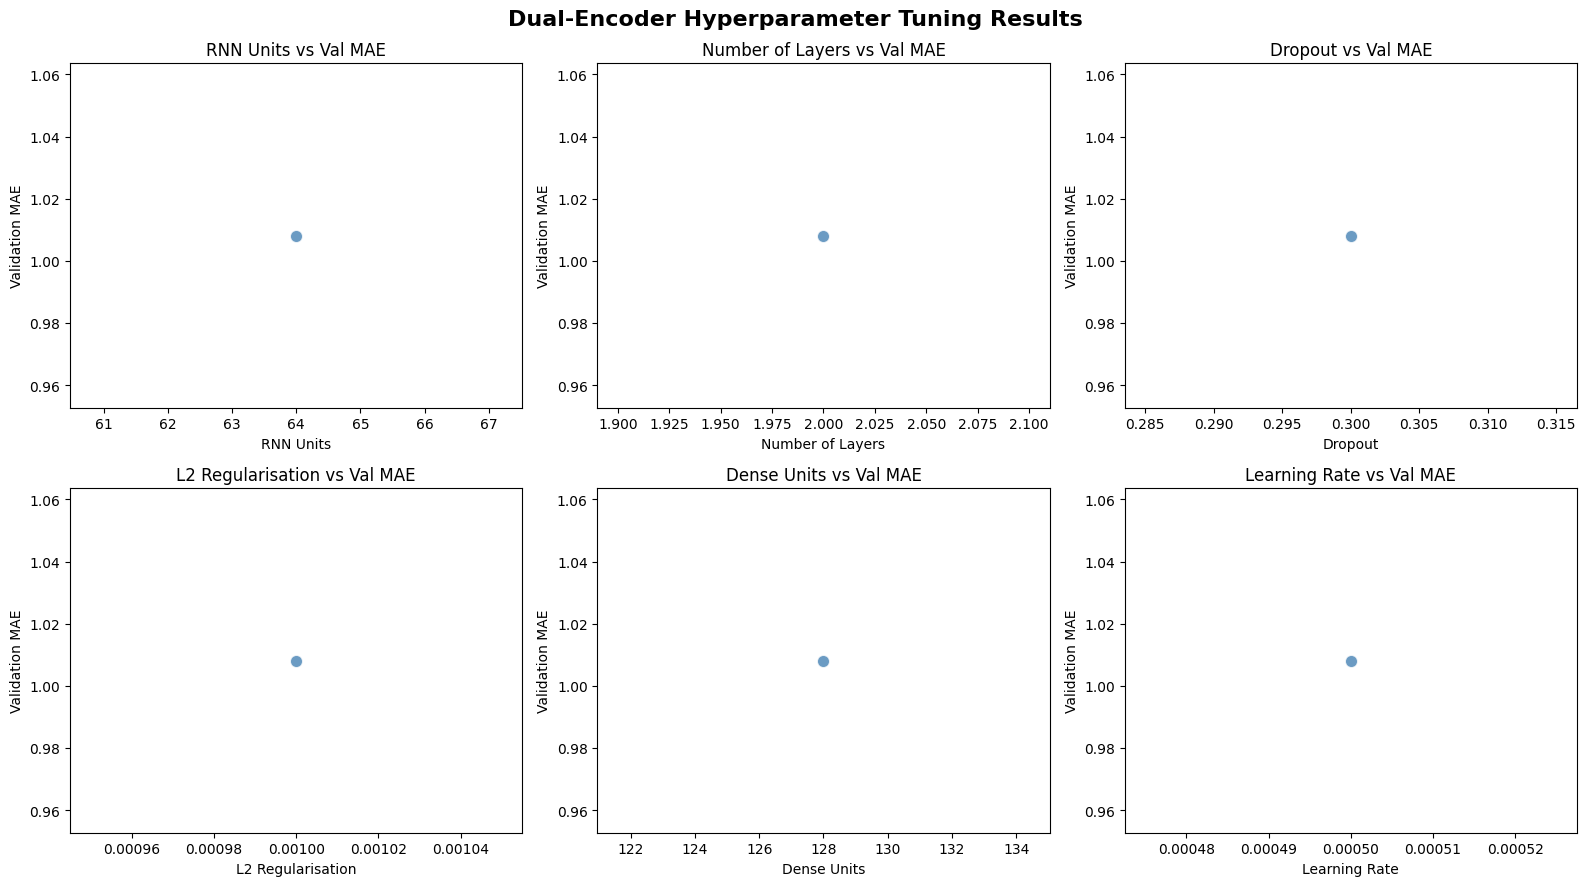

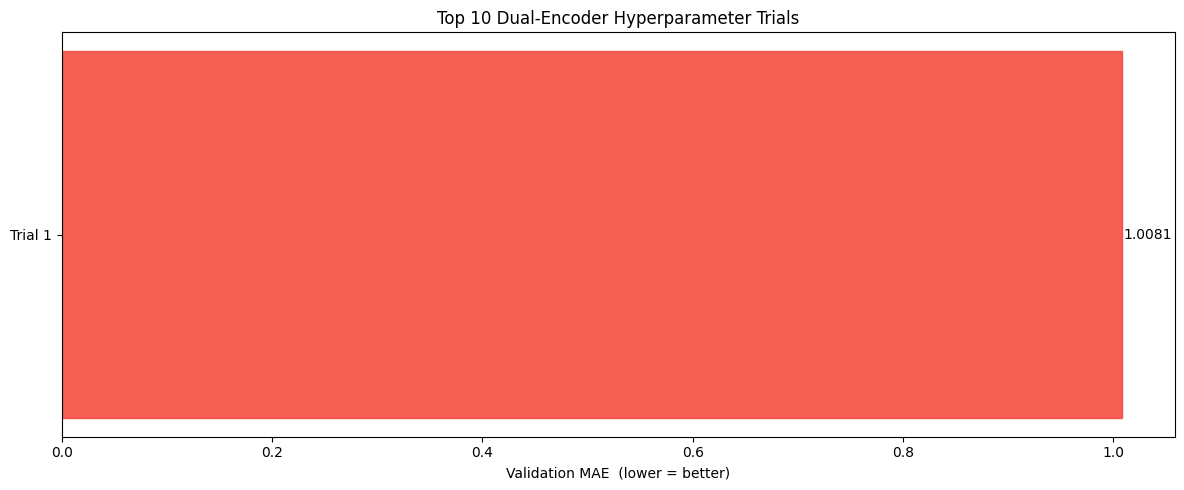

In [5]:
# ============================================================
# Dual-Encoder Visualization Script (PyTorch)
# Run after ambistory_pytorch.py — reuses its variables
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

# ------------------------------------------------------------
# 1. Predictions & Metrics
# (evaluate_loader and semeval_metrics come from the training script)
# ------------------------------------------------------------
val_preds, val_labels = evaluate_loader(best_model, val_loader)
val_preds = np.clip(val_preds, 1, 5)

stdevs    = np.maximum(s_val, 1.0)
within    = np.abs(val_preds - val_labels) <= stdevs
spear     = spearmanr(val_labels, val_preds).correlation
residuals = val_preds - val_labels

print(f"Spearman r            : {spear:.4f}")
print(f"Accuracy within std   : {within.mean():.4f}")
print(f"Mean residual         : {residuals.mean():.4f}")

# ------------------------------------------------------------
# 2. Collect Grid-Search Results
#    `all_trials` is built below from the trial loop output.
#    Re-run the grid search with history collection if needed:
#
#    all_trials = []   # reset before the loop
#    ...inside the loop, after best_trial_mae is known...
#    all_trials.append({
#        'val_mae': best_trial_mae,
#        'rnn_units': hp['rnn_units'], ...
#    })
#
#    For convenience, if all_trials isn't defined we build a
#    single-entry list from the best run.
# ------------------------------------------------------------
if 'all_trials' not in dir():
    all_trials = [{
        'val_mae':     best_val_mae,
        'rnn_units':   best_hp['rnn_units'],
        'num_layers':  best_hp['num_layers'],
        'dropout':     best_hp['dropout'],
        'l2_reg':      best_hp['l2_reg'],
        'dense_units': best_hp['dense_units'],
        'lr':          best_hp['lr'],
    }]

trial_data = sorted(all_trials, key=lambda x: x['val_mae'])

# ============================================================
# FIGURE 1 — Model Performance Overview
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Dual-Encoder Model Performance Overview',
             fontsize=16, fontweight='bold', y=1.02)

# --- 1. Predicted vs Actual ---
ax = axes[0, 0]
ax.scatter(val_labels, val_preds, alpha=0.6,
           color='steelblue', edgecolors='white', s=60)
ax.plot([1, 5], [1, 5], 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual Score')
ax.set_ylabel('Predicted Score')
ax.set_title(f'Predicted vs Actual  (Spearman r = {spear:.3f})')
ax.legend()
ax.set_xlim(0.8, 5.2)
ax.set_ylim(0.8, 5.2)

# --- 2. Residual Distribution ---
ax = axes[0, 1]
ax.hist(residuals, bins=25, color='coral', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linestyle='--', lw=2)
ax.axvline(residuals.mean(), color='red', linestyle='-', lw=2,
           label=f'Mean = {residuals.mean():.2f}')
ax.set_xlabel('Residual (Predicted − Actual)')
ax.set_ylabel('Count')
ax.set_title('Residuals Distribution')
ax.legend()

# --- 3. Accuracy Within Std Dev by Score Bucket ---
ax = axes[1, 0]
buckets     = [1, 2, 3, 4, 5]
bucket_acc  = []
for b in buckets:
    mask = (np.round(val_labels) == b)
    bucket_acc.append(within[mask].mean() if mask.sum() > 0 else 0)

bars = ax.bar(
    [str(b) for b in buckets], bucket_acc,
    color=['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336'],
    alpha=0.85
)
ax.axhline(within.mean(), color='black', linestyle='--', lw=2,
           label=f'Overall: {within.mean():.2f}')
for bar, val in zip(bars, bucket_acc):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Actual Score Bucket')
ax.set_ylabel('Accuracy Within Std Dev')
ax.set_title('Accuracy Within Std Dev by Score')
ax.set_ylim(0, 1.15)
ax.legend()

# --- 4. Score Distribution ---
ax = axes[1, 1]
bins = np.linspace(1, 5, 20)
ax.hist(val_labels, bins=bins, alpha=0.6,
        color='steelblue', label='Actual',  edgecolor='white')
ax.hist(val_preds,  bins=bins, alpha=0.6,
        color='coral',     label='Predicted', edgecolor='white')
ax.set_xlabel('Score')
ax.set_ylabel('Count')
ax.set_title('Score Distribution: Actual vs Predicted')
ax.legend()

plt.tight_layout()
plt.savefig('/content/dual_encoder_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 2 — Hyperparameter Effects
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Dual-Encoder Hyperparameter Tuning Results',
             fontsize=16, fontweight='bold')

params = [
    ('rnn_units',   'RNN Units'),
    ('num_layers',  'Number of Layers'),
    ('dropout',     'Dropout'),
    ('l2_reg',      'L2 Regularisation'),
    ('dense_units', 'Dense Units'),
    ('lr',          'Learning Rate'),
]

for ax, (param, title) in zip(axes.flat, params):
    vals   = [t[param]    for t in trial_data]
    scores = [t['val_mae'] for t in trial_data]
    ax.scatter(vals, scores, alpha=0.8, s=80, edgecolors='white',
               color='steelblue')
    ax.set_xlabel(title)
    ax.set_ylabel('Validation MAE')
    ax.set_title(f'{title} vs Val MAE')

plt.tight_layout()
plt.savefig('/content/dual_encoder_hyperparams.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# FIGURE 3 — Top 10 Trials
# ============================================================
fig, ax = plt.subplots(figsize=(12, 5))
top10  = trial_data[:10]
labels = [f"Trial {i+1}" for i in range(len(top10))]
maes   = [t['val_mae'] for t in top10]

bars = ax.barh(labels[::-1], maes[::-1], color='steelblue', alpha=0.85)
bars[-1].set_color('#4CAF50')   # best
bars[0].set_color('#F44336')    # worst in top-10

for bar, val in zip(bars, maes[::-1]):
    ax.text(bar.get_width() + 0.001,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center')

ax.set_xlabel('Validation MAE  (lower = better)')
ax.set_title('Top 10 Dual-Encoder Hyperparameter Trials')

plt.tight_layout()
plt.savefig('/content/dual_encoder_top10.png', dpi=150, bbox_inches='tight')
plt.show()
